# Classical Raster-to-Vector Comparison Notebook

This notebook compares several non-neural vectorisation approaches on synthetic 64×64 raster images containing random straight lines and Bezier curves.

Methods included:

1. **Hough Transform** — detects straight line segments.
2. **Contour tracing** — extracts object boundaries and simplifies them into polylines.
3. **Thinning / skeletonisation** — reduces strokes to one-pixel-wide centre lines, then traces them as paths.
4. **Run-graph based vectorisation** — groups continuous pixel runs in horizontal, vertical and diagonal directions.
5. **Sparse-pixel vectorisation** — traces skeleton paths but keeps only selected points.
6. **Mesh-pattern vectorisation** — divides the image into grid cells and fits local line directions using PCA.

The comparison is based on the raster similarity after vectorisation:

- IoU
- precision
- recall
- F1 score
- MAE pixel error
- vector/segment count
- processing time

The important idea is the same as your ML notebook: the exact vectors do not have to match the original hidden vectors. The main comparison is whether the reconstructed raster looks close to the original raster.

## 1. Optional install cell

Run this only if imports fail. If you already have these packages, skip it.

In [1]:
# Optional install cell. Uncomment if needed.
# %pip install numpy matplotlib pandas scipy scikit-image opencv-python tqdm

## 2. Imports and configuration

In [2]:
import math
import random
import time
from collections import defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import binary_fill_holes
from skimage import measure
from skimage.feature import canny
from skimage.morphology import skeletonize, binary_dilation, disk, remove_small_objects
from skimage.transform import probabilistic_hough_line

try:
    from IPython.display import display
except Exception:
    display = print

IMG_SIZE = 64
LINE_WIDTH = 2
MAX_ITEMS = 5
OVERHANG = 0.45
N_TEST = 30
SEED = 11

# Evaluation rasterisation width. Keep this similar to the generation width.
RASTER_WIDTH = 2

# Contour simplification and skeleton simplification.
RDP_EPSILON = 1.25
SPARSE_STRIDE = 5
MESH_GRID = 8

random.seed(SEED)
np.random.seed(SEED)

print("Ready")

Ready


## 3. Synthetic data generator

Each image contains 1 to 5 vector items. Items may be straight lines, quadratic Bezier curves or cubic Bezier curves. Points are allowed to extend outside the 64×64 image.

Line angles are sampled in 1-degree increments, but with unequal probabilities:

- multiples of 90° are most common;
- then 45°;
- then 60°;
- then 30°;
- then 20°;
- then 10°;
- then the remaining angles.

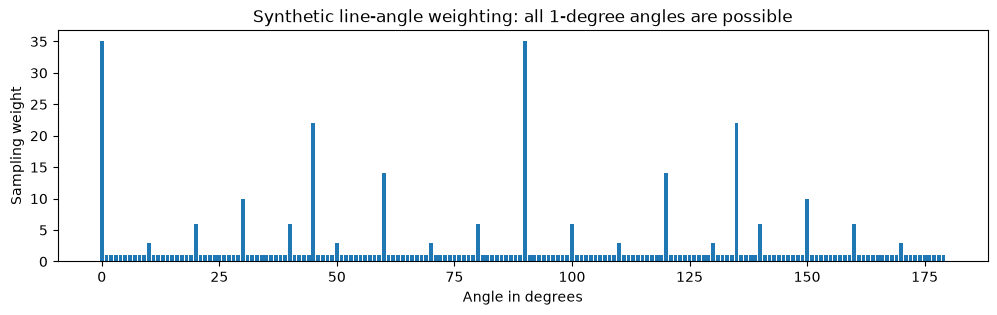

In [3]:
def make_angle_distribution():
    """Return degrees 0..179 and weighted probabilities.

    Lines are undirected, so 0..179 is enough. Every possible angle is still
    available in 1-degree increments, but common drafting angles are weighted.
    """
    degrees = np.arange(180)
    weights = np.ones_like(degrees, dtype=float)

    for i, d in enumerate(degrees):
        if d % 90 == 0:
            weights[i] = 35
        elif d % 45 == 0:
            weights[i] = 22
        elif d % 60 == 0:
            weights[i] = 14
        elif d % 30 == 0:
            weights[i] = 10
        elif d % 20 == 0:
            weights[i] = 6
        elif d % 10 == 0:
            weights[i] = 3
        else:
            weights[i] = 1

    probs = weights / weights.sum()
    return degrees, probs, weights

ANGLE_DEGREES, ANGLE_PROBS, ANGLE_WEIGHTS = make_angle_distribution()

def sample_weighted_angle_deg():
    return int(np.random.choice(ANGLE_DEGREES, p=ANGLE_PROBS))

plt.figure(figsize=(12, 3))
plt.bar(ANGLE_DEGREES, ANGLE_WEIGHTS)
plt.title("Synthetic line-angle weighting: all 1-degree angles are possible")
plt.xlabel("Angle in degrees")
plt.ylabel("Sampling weight")
plt.show()

In [4]:
def quadratic_bezier(p0, p1, p2, n=80):
    t = np.linspace(0, 1, n)[:, None]
    return (1 - t) ** 2 * p0 + 2 * (1 - t) * t * p1 + t ** 2 * p2


def cubic_bezier(p0, p1, p2, p3, n=100):
    t = np.linspace(0, 1, n)[:, None]
    return ((1 - t) ** 3 * p0
            + 3 * (1 - t) ** 2 * t * p1
            + 3 * (1 - t) * t ** 2 * p2
            + t ** 3 * p3)


def random_point(size=IMG_SIZE, overhang=OVERHANG):
    margin = size * overhang
    return np.array([
        np.random.uniform(-margin, size + margin),
        np.random.uniform(-margin, size + margin),
    ], dtype=float)


def random_line_polyline(size=IMG_SIZE):
    angle = math.radians(sample_weighted_angle_deg())
    direction = np.array([math.cos(angle), math.sin(angle)], dtype=float)

    centre = random_point(size)
    length = np.random.uniform(size * 0.25, size * 1.9)
    p0 = centre - direction * length / 2
    p1 = centre + direction * length / 2
    return np.vstack([p0, p1])


def random_curve_polyline(size=IMG_SIZE):
    kind = np.random.choice(["quadratic", "cubic"], p=[0.45, 0.55])
    if kind == "quadratic":
        p0 = random_point(size)
        p1 = random_point(size)
        p2 = random_point(size)
        return quadratic_bezier(p0, p1, p2, n=80)
    else:
        p0 = random_point(size)
        p1 = random_point(size)
        p2 = random_point(size)
        p3 = random_point(size)
        return cubic_bezier(p0, p1, p2, p3, n=100)


def rasterize_polylines(polylines, size=IMG_SIZE, width=RASTER_WIDTH):
    """Rasterise vector polylines onto a binary image.

    Coordinates are stored as x, y. Image arrays are indexed as row, col = y, x.
    """
    img = np.zeros((size, size), dtype=bool)
    for poly in polylines:
        poly = np.asarray(poly, dtype=float)
        if len(poly) < 2:
            continue
        for a, b in zip(poly[:-1], poly[1:]):
            length = float(np.linalg.norm(b - a))
            steps = max(int(length * 3), 2)
            xs = np.linspace(a[0], b[0], steps)
            ys = np.linspace(a[1], b[1], steps)
            xi = np.rint(xs).astype(int)
            yi = np.rint(ys).astype(int)
            valid = (xi >= 0) & (xi < size) & (yi >= 0) & (yi < size)
            img[yi[valid], xi[valid]] = True

    if width > 1:
        img = binary_dilation(img, disk(max(1, int(width // 2))))
    return img.astype(float)


def generate_synthetic_image(size=IMG_SIZE, max_items=MAX_ITEMS):
    n_items = np.random.randint(1, max_items + 1)
    polylines = []
    item_types = []

    for _ in range(n_items):
        # Slight line bias because the Hough/run-graph methods are line-oriented.
        if np.random.rand() < 0.58:
            polylines.append(random_line_polyline(size))
            item_types.append("line")
        else:
            polylines.append(random_curve_polyline(size))
            item_types.append("curve")

    raster = rasterize_polylines(polylines, size=size, width=LINE_WIDTH)
    return raster, polylines, item_types


def make_dataset(n=N_TEST):
    images, true_vectors, true_types = [], [], []
    for _ in range(n):
        img, vecs, types = generate_synthetic_image()
        images.append(img)
        true_vectors.append(vecs)
        true_types.append(types)
    return np.stack(images), true_vectors, true_types

images, true_vectors, true_types = make_dataset(N_TEST)
print(images.shape)

(30, 64, 64)


C:\Users\elmak\AppData\Local\Temp\ipykernel_44476\764183548.py:69: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  img = binary_dilation(img, disk(max(1, int(width // 2))))


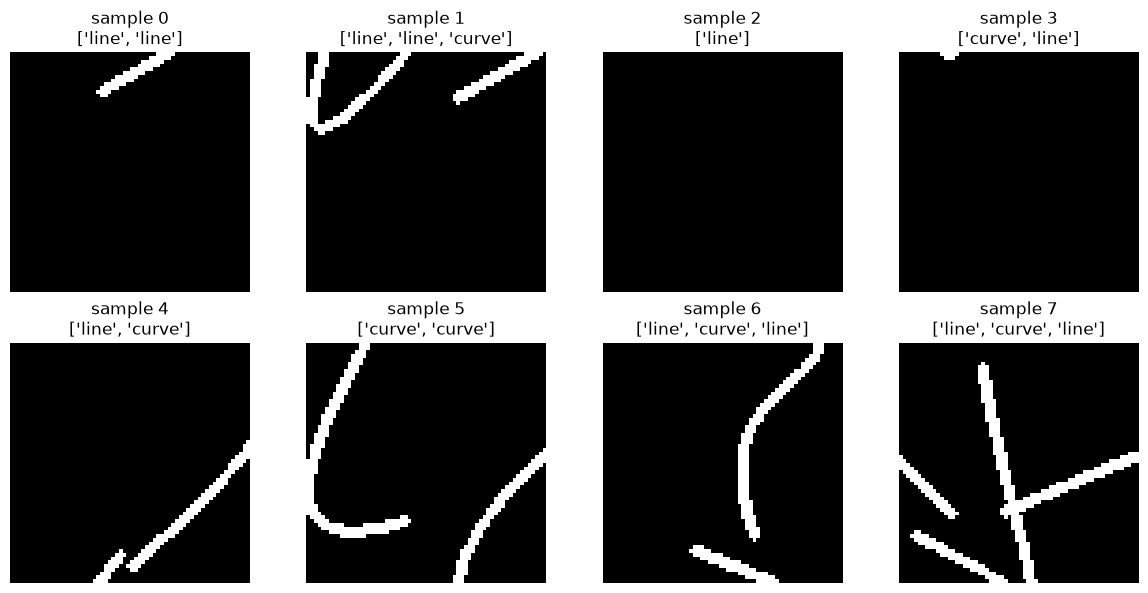

In [5]:
def show_generated_samples(n=8):
    n = min(n, len(images))
    cols = 4
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(cols * 3, rows * 3))
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i], cmap="gray", vmin=0, vmax=1)
        plt.title(f"sample {i}\n{true_types[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_generated_samples(8)

## 4. Shared utilities

All methods return vectors as a list of polylines. A polyline is a NumPy array of points in `(x, y)` order.

The comparison rasterises those polylines back into a 64×64 image and compares that reconstructed image to the original raster.

In [6]:
def clean_binary(image, threshold=0.5, min_size=2):
    binary = np.asarray(image) > threshold
    if min_size > 0:
        binary = remove_small_objects(binary, min_size=min_size)
    return binary


def rdp_simplify(points, epsilon=1.0):
    """Ramer-Douglas-Peucker polyline simplification."""
    points = np.asarray(points, dtype=float)
    if len(points) < 3:
        return points

    start = points[0]
    end = points[-1]
    line = end - start
    line_norm = np.linalg.norm(line)

    if line_norm == 0:
        distances = np.linalg.norm(points - start, axis=1)
    else:
        distances = np.abs(np.cross(line, points - start) / line_norm)

    index = int(np.argmax(distances))
    max_dist = distances[index]

    if max_dist > epsilon:
        left = rdp_simplify(points[:index + 1], epsilon)
        right = rdp_simplify(points[index:], epsilon)
        return np.vstack([left[:-1], right])
    else:
        return np.vstack([start, end])


def polyline_segment_count(polylines):
    return int(sum(max(0, len(np.asarray(p)) - 1) for p in polylines))


def raster_metrics(pred, target, threshold=0.5):
    pred_b = pred > threshold
    target_b = target > threshold

    tp = np.logical_and(pred_b, target_b).sum()
    fp = np.logical_and(pred_b, ~target_b).sum()
    fn = np.logical_and(~pred_b, target_b).sum()
    union = np.logical_or(pred_b, target_b).sum()

    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (union + 1e-9)
    mae = np.mean(np.abs(pred.astype(float) - target.astype(float)))

    return {
        "iou": float(iou),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "mae": float(mae),
    }


def vectorise_and_rasterise(method_fn, image):
    start = time.perf_counter()
    vectors = method_fn(image)
    elapsed_ms = (time.perf_counter() - start) * 1000
    reconstructed = rasterize_polylines(vectors, width=RASTER_WIDTH)
    return vectors, reconstructed, elapsed_ms

## 5. Method 1 — Hough Transform

The probabilistic Hough transform is good at finding straight line segments. It is not designed to represent curves directly, so curved strokes are usually approximated poorly unless they contain locally straight sections.

In [7]:
def vectorise_hough(image):
    binary = clean_binary(image)

    # Edges can be used, but for very small synthetic line art the binary image
    # often works better as the Hough input.
    skel = skeletonize(binary)

    lines = probabilistic_hough_line(
        skel,
        threshold=4,
        line_length=4,
        line_gap=2,
        theta=np.deg2rad(np.arange(0, 180, 1)),
        rng=SEED,
    )

    polylines = []
    for p0, p1 in lines:
        # skimage returns points as (x, y), which matches our polyline format.
        polylines.append(np.array([p0, p1], dtype=float))
    return polylines

## 6. Method 2 — Contour tracing

Contour tracing follows the boundary of foreground regions. For line drawings, this often traces the outside edge of the stroke rather than the centreline. This can produce high recall but many extra boundary vectors.

In [8]:
def vectorise_contours(image):
    binary = clean_binary(image)
    contours = measure.find_contours(binary.astype(float), level=0.5)

    polylines = []
    for contour in contours:
        if len(contour) < 2:
            continue
        # find_contours returns row, col = y, x. Convert to x, y.
        xy = np.column_stack([contour[:, 1], contour[:, 0]])
        xy = rdp_simplify(xy, epsilon=RDP_EPSILON)
        if len(xy) >= 2:
            polylines.append(xy)
    return polylines

## 7. Method 3 — Thinning / skeletonisation

Skeletonisation reduces strokes to a one-pixel-wide centreline. The code below then treats the skeleton as a graph and traces paths between endpoints and junctions.

In [9]:
NEIGHBOUR_STEPS_8 = [
    (-1, -1), (-1, 0), (-1, 1),
    (0, -1),           (0, 1),
    (1, -1),  (1, 0),  (1, 1),
]


def skeleton_neighbours(pixel, pixel_set):
    r, c = pixel
    out = []
    for dr, dc in NEIGHBOUR_STEPS_8:
        q = (r + dr, c + dc)
        if q in pixel_set:
            out.append(q)
    return out


def edge_key(a, b):
    return tuple(sorted([a, b]))


def skeleton_to_paths(skel, simplify_epsilon=RDP_EPSILON):
    skel = np.asarray(skel).astype(bool)
    pixels = set(map(tuple, np.argwhere(skel)))
    if not pixels:
        return []

    neighbours = {p: skeleton_neighbours(p, pixels) for p in pixels}
    degrees = {p: len(neighbours[p]) for p in pixels}

    # Endpoints and junctions. Degree 2 pixels are normal path pixels.
    nodes = {p for p, d in degrees.items() if d != 2}
    visited_edges = set()
    paths = []

    def walk(start, nxt):
        path = [start, nxt]
        visited_edges.add(edge_key(start, nxt))
        prev, cur = start, nxt

        while cur not in nodes:
            candidates = [q for q in neighbours[cur] if q != prev]
            if not candidates:
                break
            q = candidates[0]
            e = edge_key(cur, q)
            if e in visited_edges:
                break
            visited_edges.add(e)
            path.append(q)
            prev, cur = cur, q
        return path

    # Trace from graph nodes.
    for node in list(nodes):
        for nb in neighbours[node]:
            e = edge_key(node, nb)
            if e not in visited_edges:
                path = walk(node, nb)
                if len(path) >= 2:
                    paths.append(path)

    # Handle loops with no endpoints/junctions.
    all_edges = set()
    for p in pixels:
        for q in neighbours[p]:
            all_edges.add(edge_key(p, q))

    remaining = list(all_edges - visited_edges)
    for e in remaining:
        a, b = e
        if edge_key(a, b) in visited_edges:
            continue
        path = walk(a, b)
        if len(path) >= 2:
            paths.append(path)

    polylines = []
    for path in paths:
        arr = np.asarray(path, dtype=float)
        # Convert row, col to x, y.
        xy = np.column_stack([arr[:, 1], arr[:, 0]])
        xy = rdp_simplify(xy, epsilon=simplify_epsilon)
        if len(xy) >= 2:
            polylines.append(xy)
    return polylines


def vectorise_skeleton(image):
    binary = clean_binary(image)
    skel = skeletonize(binary)
    return skeleton_to_paths(skel, simplify_epsilon=RDP_EPSILON)

## 8. Method 4 — Run-graph based vectorisation

This method scans the skeleton for continuous runs in four directions:

- horizontal
- vertical
- diagonal down-right
- diagonal down-left

It is simple and fast, but it strongly favours those four directions. It struggles with curves and off-angle lines.

In [10]:
def vectorise_run_graph(image, min_run=3):
    binary = clean_binary(image)
    skel = skeletonize(binary)
    h, w = skel.shape

    directions = [
        (0, 1),    # horizontal
        (1, 0),    # vertical
        (1, 1),    # diagonal down-right
        (1, -1),   # diagonal down-left
    ]

    polylines = []

    for dr, dc in directions:
        for r in range(h):
            for c in range(w):
                if not skel[r, c]:
                    continue
                prev_r, prev_c = r - dr, c - dc
                if 0 <= prev_r < h and 0 <= prev_c < w and skel[prev_r, prev_c]:
                    continue

                rr, cc = r, c
                run = []
                while 0 <= rr < h and 0 <= cc < w and skel[rr, cc]:
                    run.append((rr, cc))
                    rr += dr
                    cc += dc

                if len(run) >= min_run:
                    start = run[0]
                    end = run[-1]
                    polylines.append(np.array([
                        [start[1], start[0]],
                        [end[1], end[0]],
                    ], dtype=float))

    return polylines

## 9. Method 5 — Sparse-pixel vectorisation

This method first skeletonises the raster, traces skeleton paths, and then keeps only a sparse set of points from each path. It can reduce vector complexity while often preserving a similar raster result.

In [11]:
def vectorise_sparse_pixels(image, stride=SPARSE_STRIDE):
    binary = clean_binary(image)
    skel = skeletonize(binary)
    dense_paths = skeleton_to_paths(skel, simplify_epsilon=0.0)

    sparse_paths = []
    for path in dense_paths:
        path = np.asarray(path, dtype=float)
        if len(path) < 2:
            continue
        keep = list(range(0, len(path), stride))
        if keep[-1] != len(path) - 1:
            keep.append(len(path) - 1)
        sparse = path[keep]
        sparse = rdp_simplify(sparse, epsilon=RDP_EPSILON)
        if len(sparse) >= 2:
            sparse_paths.append(sparse)
    return sparse_paths

## 10. Method 6 — Mesh-pattern vectorisation

This method divides the image into a regular grid. In each cell, it fits a local line direction using PCA over the foreground pixels. It produces many short local segments rather than global object vectors.

This is useful as a rough structural approximation, especially when the raster has many short fragmented strokes.

In [12]:
def vectorise_mesh_pattern(image, grid=MESH_GRID, min_pixels=2):
    binary = clean_binary(image)
    h, w = binary.shape
    cell_h = h / grid
    cell_w = w / grid
    polylines = []

    for gy in range(grid):
        for gx in range(grid):
            r0 = int(round(gy * cell_h))
            r1 = int(round((gy + 1) * cell_h))
            c0 = int(round(gx * cell_w))
            c1 = int(round((gx + 1) * cell_w))

            patch = binary[r0:r1, c0:c1]
            ys, xs = np.where(patch)
            if len(xs) < min_pixels:
                continue

            pts = np.column_stack([xs + c0, ys + r0]).astype(float)
            centre = pts.mean(axis=0)

            if len(pts) >= 2:
                centred = pts - centre
                cov = centred.T @ centred / max(len(pts) - 1, 1)
                eigvals, eigvecs = np.linalg.eigh(cov)
                direction = eigvecs[:, np.argmax(eigvals)]
                direction = direction / (np.linalg.norm(direction) + 1e-9)
                length = min(cell_w, cell_h) * 0.85
            else:
                direction = np.array([1.0, 0.0])
                length = min(cell_w, cell_h) * 0.5

            p0 = centre - direction * length / 2
            p1 = centre + direction * length / 2
            polylines.append(np.vstack([p0, p1]))

    return polylines

## 11. Compare methods on the synthetic dataset

In [13]:
METHODS = {
    "Hough Transform": vectorise_hough,
    "Contour": vectorise_contours,
    "Skeletonisation": vectorise_skeleton,
    "Run-graph": vectorise_run_graph,
    "Sparse pixel": vectorise_sparse_pixels,
    "Mesh pattern": vectorise_mesh_pattern,
}


def evaluate_methods(images):
    rows = []
    outputs = defaultdict(dict)

    for image_idx, image in enumerate(images):
        for method_name, method_fn in METHODS.items():
            vectors, reconstructed, elapsed_ms = vectorise_and_rasterise(method_fn, image)
            stats = raster_metrics(reconstructed, image)
            rows.append({
                "image_idx": image_idx,
                "method": method_name,
                "segments": polyline_segment_count(vectors),
                "polylines": len(vectors),
                "time_ms": elapsed_ms,
                **stats,
            })
            outputs[image_idx][method_name] = {
                "vectors": vectors,
                "reconstructed": reconstructed,
            }

    return pd.DataFrame(rows), outputs

results_df, method_outputs = evaluate_methods(images)
summary_df = (
    results_df
    .groupby("method")
    .agg({
        "iou": "mean",
        "precision": "mean",
        "recall": "mean",
        "f1": "mean",
        "mae": "mean",
        "segments": "mean",
        "polylines": "mean",
        "time_ms": "mean",
    })
    .sort_values("f1", ascending=False)
)

summary_df

C:\Users\elmak\AppData\Local\Temp\ipykernel_44476\3945976460.py:4: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  binary = remove_small_objects(binary, min_size=min_size)
C:\Users\elmak\AppData\Local\Temp\ipykernel_44476\764183548.py:69: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  img = binary_dilation(img, disk(max(1, int(width // 2))))
C:\Users\elmak\AppData\Local\Temp\ipykernel_44476\3945976460.py:22: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated.

,iou,precision,recall,f1,mae,segments,polylines,time_ms
method,,,,,,,,
Skeletonisation,0.649698,0.721580,0.741211,0.728934,0.015967,11.800000,8.966667,1.170507
Mesh pattern,0.614660,0.646623,0.783119,0.700599,0.020492,15.133333,15.133333,1.507370
Hough Transform,0.620618,0.718241,0.683055,0.698241,0.016195,7.000000,7.000000,0.756220
Run-graph,0.572755,0.758963,0.600364,0.663847,0.018538,14.166667,14.166667,1.961643
Sparse pixel,0.553291,0.661316,0.668513,0.662241,0.025952,10.733333,8.966667,2.847917
Contour,0.386848,0.400336,0.779223,0.527229,0.066349,12.933333,3.000000,2.246530


In [14]:
# Show the full per-image results as well.
results_df.head(12)

,image_idx,method,segments,polylines,time_ms,iou,precision,recall,f1,mae
0,0,Hough Transform,2,2,3.8417,0.897059,0.938462,0.953125,0.945736,0.001709
1,0,Contour,4,1,23.3586,0.440299,0.457364,0.921875,0.611399,0.018311
2,0,Skeletonisation,1,1,0.6702,0.760000,0.838235,0.890625,0.863636,0.004395
3,0,Run-graph,4,4,1.8641,0.560606,0.948718,0.578125,0.718447,0.007080
4,0,Sparse pixel,1,1,1.2359,0.760000,0.838235,0.890625,0.863636,0.004395
5,0,Mesh pattern,4,4,3.8448,0.790123,0.790123,1.000000,0.882759,0.004150
6,1,Hough Transform,6,6,0.6435,0.804167,0.910377,0.873303,0.891455,0.011475
7,1,Contour,12,4,1.3564,0.470046,0.489209,0.923077,0.639498,0.056152
8,1,Skeletonisation,5,2,1.0565,0.742972,0.868545,0.837104,0.852535,0.015625
9,1,Run-graph,10,10,1.9581,0.669604,0.962025,0.687783,0.802111,0.018311


## 12. Plot method comparison

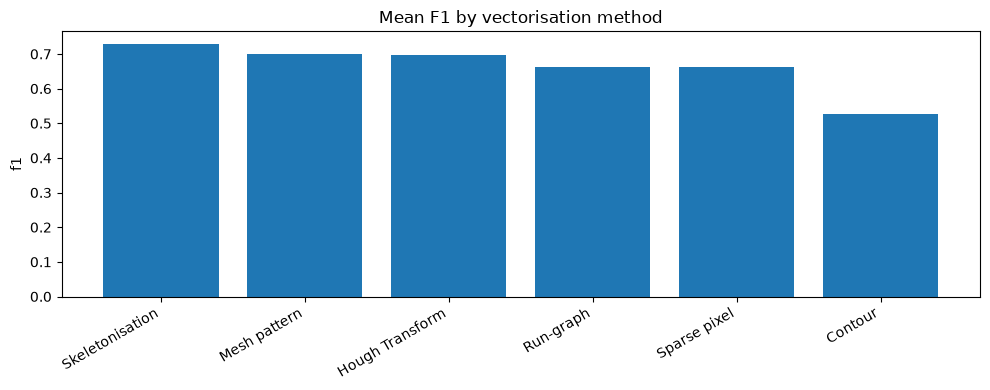

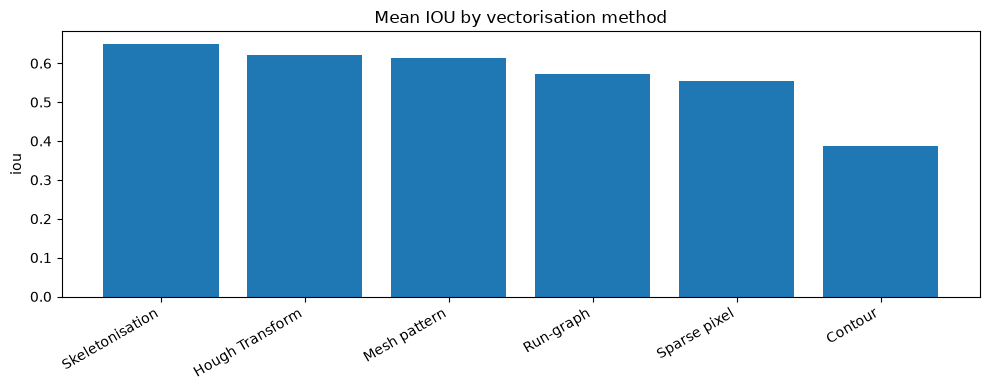

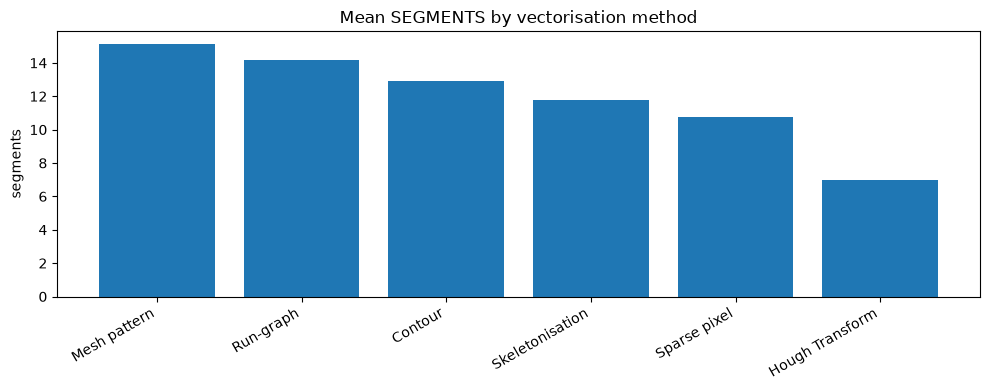

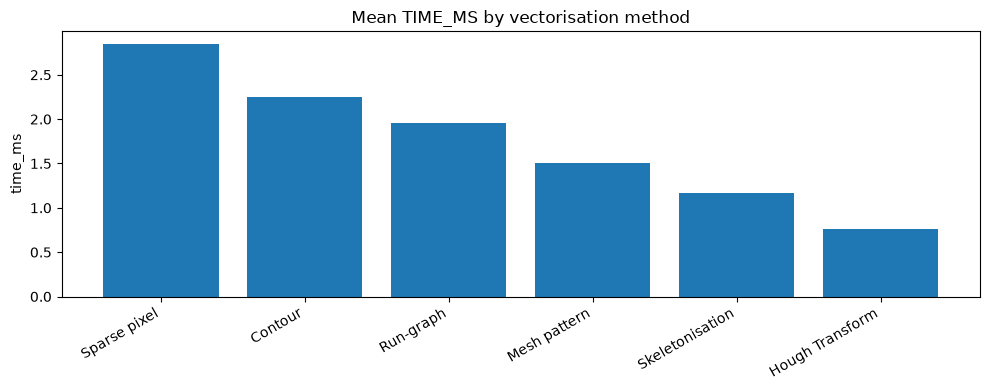

In [15]:
def plot_metric_bar(summary, metric="f1"):
    ordered = summary.sort_values(metric, ascending=False)
    plt.figure(figsize=(10, 4))
    plt.bar(ordered.index, ordered[metric])
    plt.title(f"Mean {metric.upper()} by vectorisation method")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

plot_metric_bar(summary_df, "f1")
plot_metric_bar(summary_df, "iou")
plot_metric_bar(summary_df, "segments")
plot_metric_bar(summary_df, "time_ms")

## 13. Visual comparison for one sample

The first image is the original raster. Each following image is reconstructed from the vectors produced by one method.

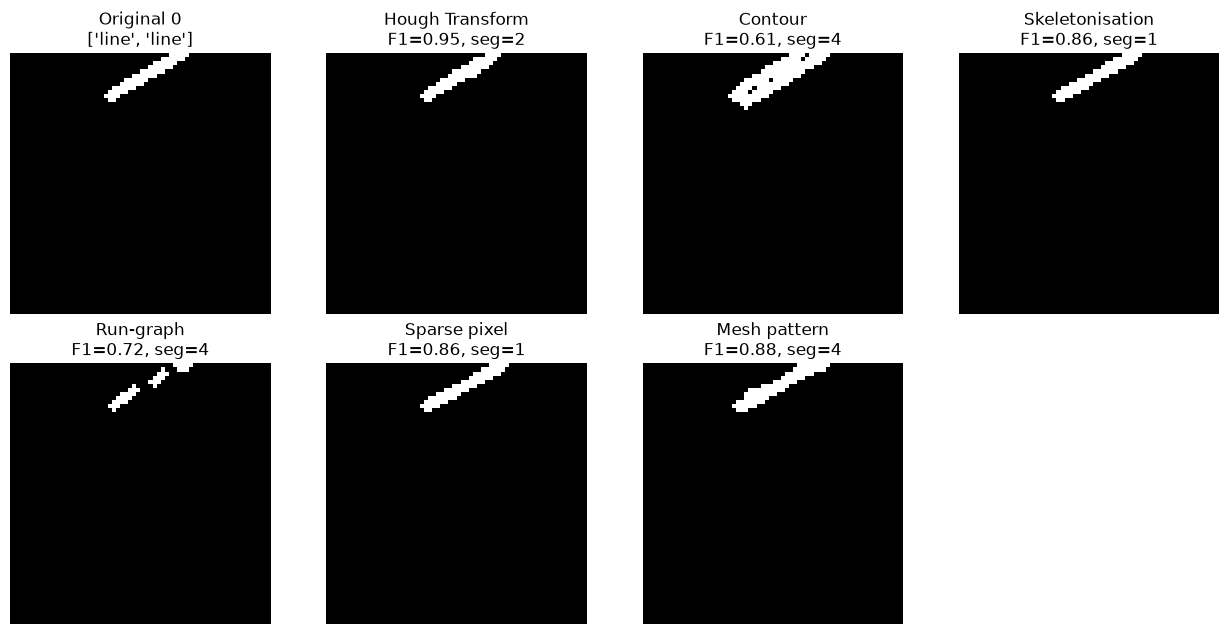

In [16]:
def plot_sample_comparison(sample_idx=0):
    method_names = list(METHODS.keys())
    n_panels = 1 + len(method_names)
    cols = 4
    rows = int(math.ceil(n_panels / cols))

    plt.figure(figsize=(cols * 3.2, rows * 3.2))

    plt.subplot(rows, cols, 1)
    plt.imshow(images[sample_idx], cmap="gray", vmin=0, vmax=1)
    plt.title(f"Original {sample_idx}\n{true_types[sample_idx]}")
    plt.axis("off")

    for i, name in enumerate(method_names, start=2):
        recon = method_outputs[sample_idx][name]["reconstructed"]
        row = results_df[(results_df.image_idx == sample_idx) & (results_df.method == name)].iloc[0]
        plt.subplot(rows, cols, i)
        plt.imshow(recon, cmap="gray", vmin=0, vmax=1)
        plt.title(f"{name}\nF1={row.f1:.2f}, seg={int(row.segments)}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_sample_comparison(0)

## 14. Overlay comparison

This view shows where each method agrees or disagrees with the original raster:

- black background: true negative
- grey: original raster only / missed pixels
- white: reconstructed pixels

For a more detailed colour overlay, use the next cell.

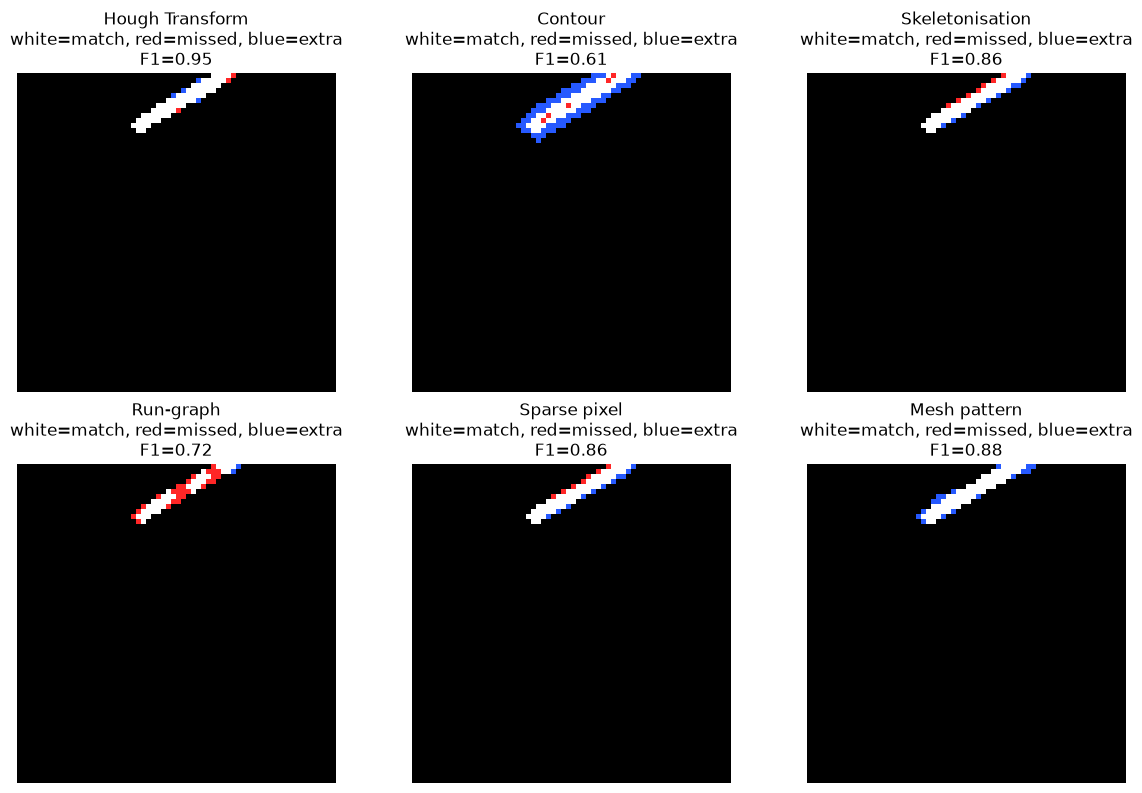

In [17]:
def make_error_overlay(target, pred):
    """Return RGB overlay: target-only red, pred-only blue, overlap white."""
    t = target > 0.5
    p = pred > 0.5
    rgb = np.zeros((*target.shape, 3), dtype=float)
    rgb[np.logical_and(t, p)] = [1.0, 1.0, 1.0]
    rgb[np.logical_and(t, ~p)] = [1.0, 0.15, 0.15]
    rgb[np.logical_and(~t, p)] = [0.15, 0.35, 1.0]
    return rgb


def plot_error_overlays(sample_idx=0):
    method_names = list(METHODS.keys())
    cols = 3
    rows = int(math.ceil(len(method_names) / cols))

    plt.figure(figsize=(cols * 4, rows * 4))
    for i, name in enumerate(method_names, start=1):
        recon = method_outputs[sample_idx][name]["reconstructed"]
        overlay = make_error_overlay(images[sample_idx], recon)
        row = results_df[(results_df.image_idx == sample_idx) & (results_df.method == name)].iloc[0]
        plt.subplot(rows, cols, i)
        plt.imshow(overlay)
        plt.title(f"{name}\nwhite=match, red=missed, blue=extra\nF1={row.f1:.2f}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_error_overlays(0)

## 15. Draw vector overlays

This plots the original raster in grey and overlays the vector polylines produced by each method.

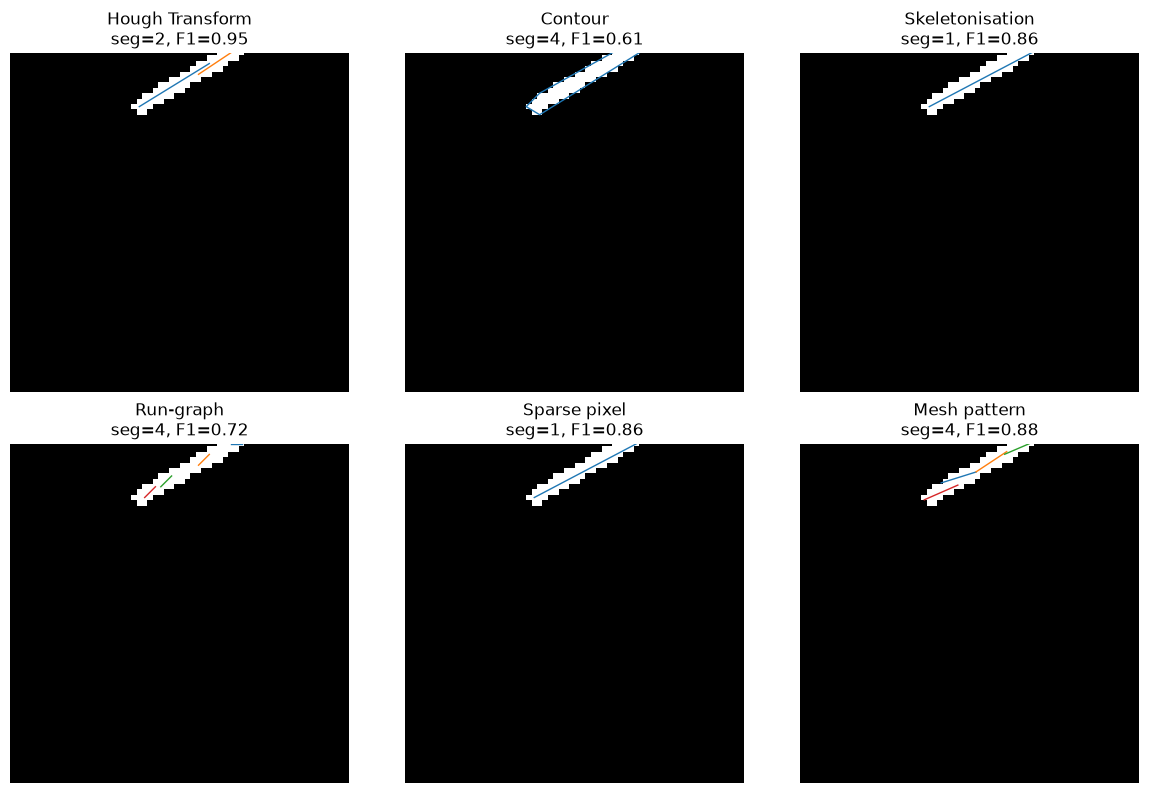

In [18]:
def plot_vectors_on_image(sample_idx=0):
    method_names = list(METHODS.keys())
    cols = 3
    rows = int(math.ceil(len(method_names) / cols))

    plt.figure(figsize=(cols * 4, rows * 4))
    for i, name in enumerate(method_names, start=1):
        vectors = method_outputs[sample_idx][name]["vectors"]
        row = results_df[(results_df.image_idx == sample_idx) & (results_df.method == name)].iloc[0]

        plt.subplot(rows, cols, i)
        plt.imshow(images[sample_idx], cmap="gray", vmin=0, vmax=1)
        for poly in vectors:
            poly = np.asarray(poly)
            if len(poly) >= 2:
                plt.plot(poly[:, 0], poly[:, 1], linewidth=1)
        plt.xlim(0, IMG_SIZE - 1)
        plt.ylim(IMG_SIZE - 1, 0)
        plt.title(f"{name}\nseg={int(row.segments)}, F1={row.f1:.2f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_vectors_on_image(0)

## 16. Try a different sample

Change `sample_idx` to inspect different images.

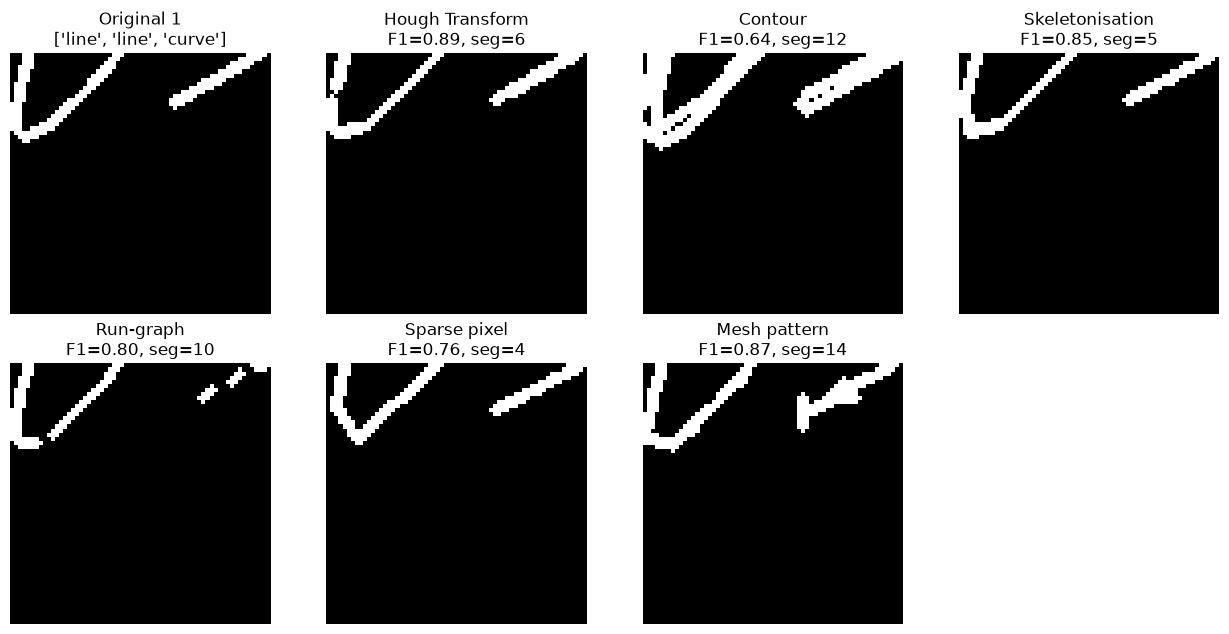

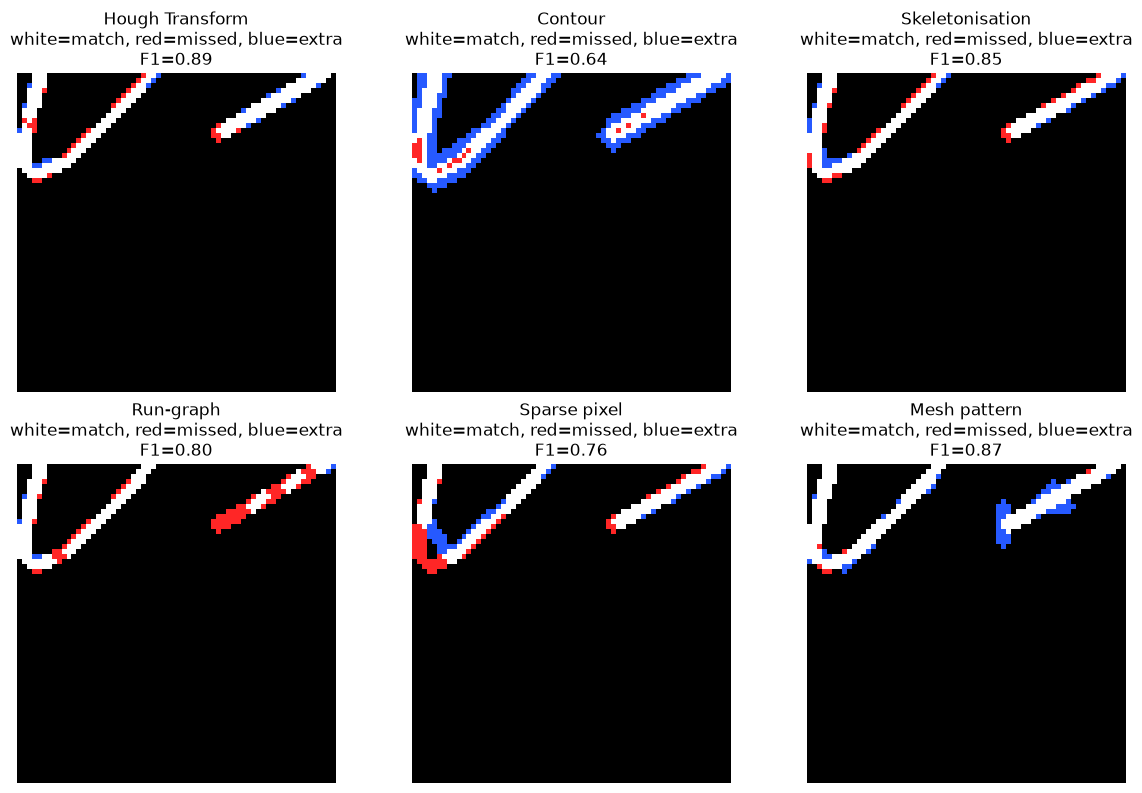

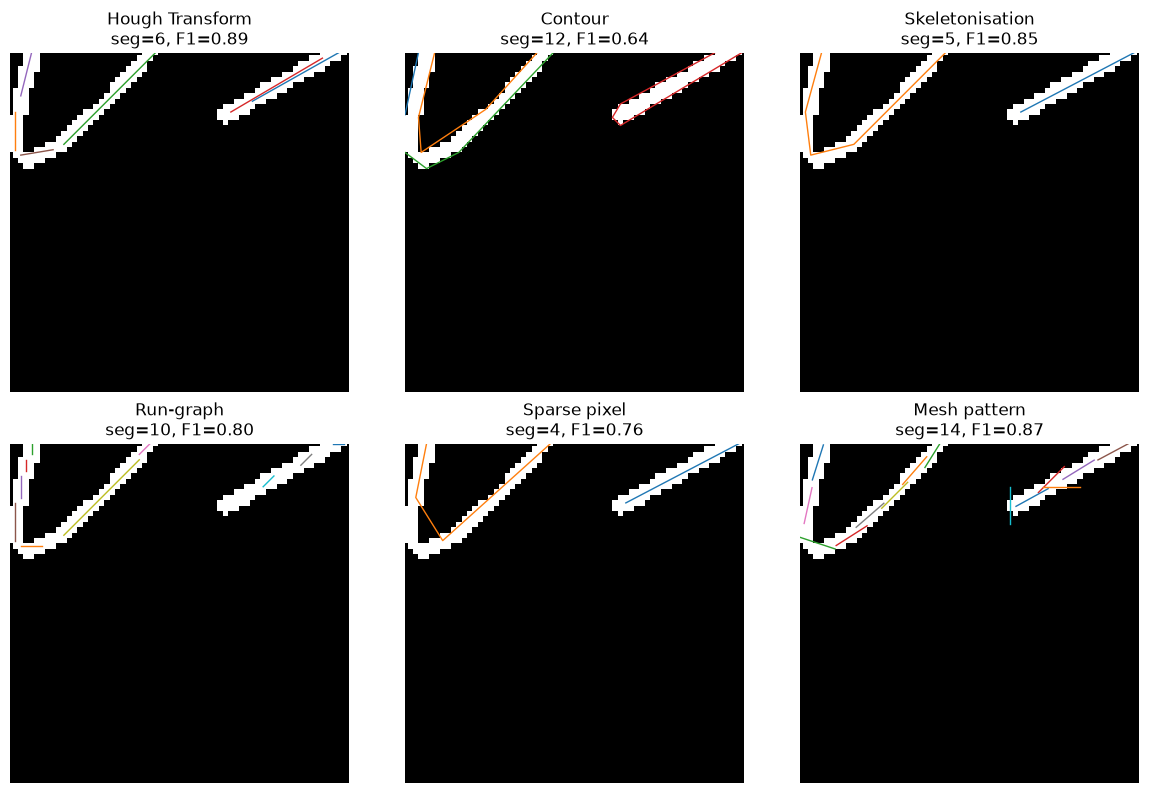

In [19]:
sample_idx = 1
plot_sample_comparison(sample_idx)
plot_error_overlays(sample_idx)
plot_vectors_on_image(sample_idx)

## 17. Save vectors as SVG

This is useful if you want to inspect the vector output outside Python.

In [20]:
def polylines_to_svg(polylines, filename, size=IMG_SIZE, stroke_width=1.0):
    def fmt_points(poly):
        return " ".join(f"{float(x):.2f},{float(y):.2f}" for x, y in poly)

    lines = [
        f'<svg xmlns="http://www.w3.org/2000/svg" width="{size}" height="{size}" viewBox="0 0 {size} {size}">',
        '<rect width="100%" height="100%" fill="white"/>',
    ]

    for poly in polylines:
        poly = np.asarray(poly)
        if len(poly) < 2:
            continue
        lines.append(
            f'<polyline points="{fmt_points(poly)}" fill="none" stroke="black" '
            f'stroke-width="{stroke_width}" stroke-linecap="round" stroke-linejoin="round" />'
        )

    lines.append('</svg>')

    with open(filename, 'w', encoding='utf-8') as f:
        f.write("\n".join(lines))

    print(f"Saved {filename}")

# Example: save the best-F1 method for sample 0.
best_method = summary_df.index[0]
polylines_to_svg(method_outputs[0][best_method]["vectors"], f"sample_0_{best_method.replace(' ', '_')}.svg")

Saved sample_0_Skeletonisation.svg


## 18. Interpretation guide

Typical behaviour:

- **Hough Transform**: strong on straight lines, weak on curves.
- **Contour**: often high recall, but it traces stroke boundaries rather than centre lines, so it can use many vectors.
- **Skeletonisation**: usually a good centreline baseline for line drawings and curves.
- **Run-graph**: simple and fast, but biased toward horizontal, vertical and diagonal runs.
- **Sparse pixel**: can reduce vector count, but may lose detail on tight curves.
- **Mesh pattern**: gives a local structural approximation, but can create many short disconnected segments.

For your project, skeletonisation and sparse skeleton paths are useful classical baselines to compare against the neural differentiable rasterisation model. Hough is useful as a line-specific baseline, especially for images dominated by straight CAD-like lines.

## 19. Notes for extending this notebook

Good next experiments:

1. Add noise, blur, gaps or compression artefacts to the synthetic rasters.
2. Separate the test set into `line-only`, `curve-only`, and `mixed` images.
3. Add curve fitting after skeletonisation, for example fitting Bezier curves to traced skeleton paths.
4. Compare against your neural model by feeding both methods the same generated dataset.
5. Add a vector-count penalty so the best method is not only the closest raster match but also the simplest vector representation.

## References used for implementation ideas

- scikit-image documentation: `probabilistic_hough_line`, `find_contours`, and `skeletonize`.
- OpenCV documentation/tutorials: Hough line transform concepts.

These references are useful for explaining the classical methods in your report, but this notebook uses its own small helper implementations for tracing skeleton paths, run graphs, sparse pixels and mesh-pattern local PCA.